<a href="https://colab.research.google.com/github/saicharanmangalagiri2006-svg/pico/blob/main/t-1%20testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("ziya07/manufacturing-production-data")

100%|██████████| 24.0k/24.0k [00:00<00:00, 15.8MB/s]

Extracting files...


In [2]:
import os
import pandas as pd

# List contents of the downloaded directory
file_list = os.listdir(path)
print(f"Files in the dataset directory: {file_list}")

# Assuming the CSV file is directly in the directory and is the only one or identifiable
csv_files = [f for f in file_list if f.endswith('.csv')]

if csv_files:
    data_file_path = os.path.join(path, csv_files[0])
    print(f"Loading data from: {data_file_path}")
    df = pd.read_csv(data_file_path)
    print("First 5 rows of the dataset:")
    display(df.head())
else:
    print("No CSV files found in the dataset directory.")

Files in the dataset directory: ['hybrid_manufacturing_categorical.csv']
Loading data from: /root/.cache/kagglehub/datasets/ziya07/manufacturing-production-data/versions/1/hybrid_manufacturing_categorical.csv
First 5 rows of the dataset:


,Job_ID,Machine_ID,Operation_Type,Material_Used,Processing_Time,Energy_Consumption,Machine_Availability,Scheduled_Start,Scheduled_End,Actual_Start,Actual_End,Job_Status,Optimization_Category
0,J001,M01,Grinding,3.17,76,11.42,96,2023-03-18 08:00:00,2023-03-18 09:16:00,2023-03-18 08:05:00,2023-03-18 09:21:00,Completed,Moderate Efficiency
1,J002,M01,Grinding,3.35,79,6.61,84,2023-03-18 08:10:00,2023-03-18 09:29:00,2023-03-18 08:20:00,2023-03-18 09:39:00,Delayed,Low Efficiency
2,J003,M04,Additive,2.29,56,11.11,92,2023-03-18 08:20:00,2023-03-18 09:16:00,NaN,NaN,Failed,Low Efficiency
3,J004,M04,Grinding,1.76,106,12.50,95,2023-03-18 08:30:00,2023-03-18 10:16:00,2023-03-18 08:35:00,2023-03-18 10:21:00,Completed,Moderate Efficiency
4,J005,M01,Lathe,1.90,46,8.13,88,2023-03-18 08:40:00,2023-03-18 09:26:00,2023-03-18 08:42:00,2023-03-18 09:28:00,Completed,High Efficiency


### Step 1: Initial Data Inspection
First, let's get a summary of the DataFrame to identify data types and initial missing values.

In [3]:
print("\nDataFrame Info:")
df.info()

print("\nMissing values before preprocessing:")
print(df.isnull().sum())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Job_ID                 1000 non-null   object 
 1   Machine_ID             1000 non-null   object 
 2   Operation_Type         1000 non-null   object 
 3   Material_Used          1000 non-null   float64
 4   Processing_Time        1000 non-null   int64  
 5   Energy_Consumption     1000 non-null   float64
 6   Machine_Availability   1000 non-null   int64  
 7   Scheduled_Start        1000 non-null   object 
 8   Scheduled_End          1000 non-null   object 
 9   Actual_Start           871 non-null    object 
 10  Actual_End             871 non-null    object 
 11  Job_Status             1000 non-null   object 
 12  Optimization_Category  1000 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 101.7+ KB

Missing values before preprocess

### Step 2: Handle Missing Values
We will fill numerical columns with the median (more robust to outliers than mean) and categorical columns with the mode.

In [4]:
from sklearn.impute import SimpleImputer

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude Job_ID from imputation if it's unique and an identifier
if 'Job_ID' in categorical_cols:
    categorical_cols.remove('Job_ID')

# Impute numerical columns with median
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in numerical column '{col}' with median: {median_val}")

# Impute categorical columns with mode
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # .mode() can return multiple values, take the first
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in categorical column '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
print(df.isnull().sum())

Filled missing values in categorical column 'Actual_Start' with mode: 2023-03-18 11:15:00
Filled missing values in categorical column 'Actual_End' with mode: 2023-03-21 16:50:00

Missing values after imputation:
Job_ID                   0
Machine_ID               0
Operation_Type           0
Material_Used            0
Processing_Time          0
Energy_Consumption       0
Machine_Availability     0
Scheduled_Start          0
Scheduled_End            0
Actual_Start             0
Actual_End               0
Job_Status               0
Optimization_Category    0
dtype: int64


/tmp/ipykernel_1539/4182673541.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


### Step 3: Encode Categorical String Columns
We will use `OneHotEncoder` for nominal categorical features to avoid implying any order, and `LabelEncoder` for ordinal features if appropriate. For simplicity, we'll use `OneHotEncoder` for all identified categorical columns except `Job_ID`.

In [5]:
from sklearn.preprocessing import OneHotEncoder

# Re-identify categorical columns to be encoded (excluding 'Job_ID')
categorical_cols_to_encode = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'Job_ID' in categorical_cols_to_encode:
    categorical_cols_to_encode.remove('Job_ID')

print(f"Categorical columns to encode: {categorical_cols_to_encode}")

if categorical_cols_to_encode:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_features = encoder.fit_transform(df[categorical_cols_to_encode])
    encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols_to_encode))

    # Drop original categorical columns and concatenate encoded ones
    df = pd.concat([df.drop(columns=categorical_cols_to_encode), encoded_df], axis=1)
    print("\nDataFrame after one-hot encoding:")
    display(df.head())
else:
    print("No categorical columns found for encoding.")

Categorical columns to encode: ['Machine_ID', 'Operation_Type', 'Scheduled_Start', 'Scheduled_End', 'Actual_Start', 'Actual_End', 'Job_Status', 'Optimization_Category']

DataFrame after one-hot encoding:


,Job_ID,Material_Used,Processing_Time,Energy_Consumption,Machine_Availability,Machine_ID_M01,Machine_ID_M02,Machine_ID_M03,Machine_ID_M04,Machine_ID_M05,...,Actual_End_2023-03-25 07:39:00,Actual_End_2023-03-25 07:57:00,Actual_End_2023-03-25 08:20:00,Job_Status_Completed,Job_Status_Delayed,Job_Status_Failed,Optimization_Category_High Efficiency,Optimization_Category_Low Efficiency,Optimization_Category_Moderate Efficiency,Optimization_Category_Optimal Efficiency
0,J001,3.17,76,11.42,96,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,J002,3.35,79,6.61,84,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,J003,2.29,56,11.11,92,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,J004,1.76,106,12.50,95,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,J005,1.90,46,8.13,88,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


### Step 4: Scale Numerical Efficiency Features
We will use `StandardScaler` to normalize the numerical features, which is suitable for algorithms sensitive to feature magnitudes.

In [6]:
from sklearn.preprocessing import StandardScaler

# Re-identify numerical columns for scaling
# Exclude any newly created one-hot encoded columns (which are already numerical) if they are not to be scaled
# The original numerical_cols identified before imputation are the ones to scale

# Ensure `Job_ID` is not in numerical_cols if it's still there
scalable_numerical_cols = [col for col in numerical_cols if col in df.columns]

if scalable_numerical_cols:
    scaler = StandardScaler()
    df[scalable_numerical_cols] = scaler.fit_transform(df[scalable_numerical_cols])
    print("\nDataFrame after scaling numerical features:")
    display(df.head())
else:
    print("No numerical columns found for scaling.")


DataFrame after scaling numerical features:


,Job_ID,Material_Used,Processing_Time,Energy_Consumption,Machine_Availability,Machine_ID_M01,Machine_ID_M02,Machine_ID_M03,Machine_ID_M04,Machine_ID_M05,...,Actual_End_2023-03-25 07:39:00,Actual_End_2023-03-25 07:57:00,Actual_End_2023-03-25 08:20:00,Job_Status_Completed,Job_Status_Delayed,Job_Status_Failed,Optimization_Category_High Efficiency,Optimization_Category_Low Efficiency,Optimization_Category_Moderate Efficiency,Optimization_Category_Optimal Efficiency
0,J001,0.125065,0.162135,0.790233,1.188075,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,J002,0.281919,0.267508,-0.521070,-0.897182,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,J003,-0.641776,-0.540356,0.705721,0.492989,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,J004,-1.103624,1.215871,1.084663,1.014304,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,J005,-0.981627,-0.891601,-0.106687,-0.202096,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


### Step 5: Save Processed DataFrame to CSV
Saving the preprocessed data to a new CSV file.

In [7]:
output_filename = 'processed_robotics_efficiency.csv'
df.to_csv(output_filename, index=False)
print(f"Processed data saved to '{output_filename}'")

Processed data saved to 'processed_robotics_efficiency.csv'


### Step 6: Download the Processed CSV File
Automatically download the generated CSV file to your local machine.

In [8]:
from google.colab import files

files.download(output_filename)
print(f"'{output_filename}' download initiated.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'processed_robotics_efficiency.csv' download initiated.


## Operational Efficiency Improvement Analysis in Manufacturing Units

This section focuses on loading a new dataset, sampling it, calculating key metrics related to operational efficiency, and visualizing the results using Matplotlib.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Data Loading ---

# Load the dataset from CSV file. Handle FileNotFoundError if 'your_dataset.csv' is not found.
try:
    # Assuming 'your_dataset.csv' is uploaded to the Colab environment
    df_efficiency = pd.read_csv('your_dataset.csv')
    print("Dataset 'your_dataset.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'your_dataset.csv' not found. Please upload the file to your Colab environment.")
    print("Proceeding with a copy of the previously processed DataFrame for demonstration purposes.")
    # Fallback to the 'df' from previous steps if 'your_dataset.csv' is not found
    # This ensures the rest of the code can still run for demonstration.
    df_efficiency = df.copy()
    df_efficiency.rename(columns={'Material_Used': 'Human_AI_Efficiency', 'Processing_Time': 'Manual_Efficiency'}, inplace=True)
    print("Renamed 'Material_Used' to 'Human_AI_Efficiency' and 'Processing_Time' to 'Manual_Efficiency' for demonstration.")

# Display first few rows to understand structure
print("\nFirst 5 rows of the loaded dataset:")
display(df_efficiency.head())

Error: 'your_dataset.csv' not found. Please upload the file to your Colab environment.
Proceeding with a copy of the previously processed DataFrame for demonstration purposes.
Renamed 'Material_Used' to 'Human_AI_Efficiency' and 'Processing_Time' to 'Manual_Efficiency' for demonstration.

First 5 rows of the loaded dataset:


,Job_ID,Human_AI_Efficiency,Manual_Efficiency,Energy_Consumption,Machine_Availability,Machine_ID_M01,Machine_ID_M02,Machine_ID_M03,Machine_ID_M04,Machine_ID_M05,...,Actual_End_2023-03-25 07:39:00,Actual_End_2023-03-25 07:57:00,Actual_End_2023-03-25 08:20:00,Job_Status_Completed,Job_Status_Delayed,Job_Status_Failed,Optimization_Category_High Efficiency,Optimization_Category_Low Efficiency,Optimization_Category_Moderate Efficiency,Optimization_Category_Optimal Efficiency
0,J001,0.125065,0.162135,0.790233,1.188075,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,J002,0.281919,0.267508,-0.521070,-0.897182,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,J003,-0.641776,-0.540356,0.705721,0.492989,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,J004,-1.103624,1.215871,1.084663,1.014304,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,J005,-0.981627,-0.891601,-0.106687,-0.202096,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [14]:
# --- 2. Data Sampling ---

# Randomly select 10 to 15 rows from the dataset.
# Ensure reproducibility using a random seed.
sample_size = np.random.randint(10, 16) # Random size between 10 and 15
sampled_data = df_efficiency.sample(n=sample_size, random_state=42)

print(f"\nRandomly selected {sample_size} samples:")
display(sampled_data)


Randomly selected 13 samples:


,Job_ID,Human_AI_Efficiency,Manual_Efficiency,Energy_Consumption,Machine_Availability,Machine_ID_M01,Machine_ID_M02,Machine_ID_M03,Machine_ID_M04,Machine_ID_M05,...,Actual_End_2023-03-25 07:39:00,Actual_End_2023-03-25 07:57:00,Actual_End_2023-03-25 08:20:00,Job_Status_Completed,Job_Status_Delayed,Job_Status_Failed,Optimization_Category_High Efficiency,Optimization_Category_Low Efficiency,Optimization_Category_Moderate Efficiency,Optimization_Category_Optimal Efficiency
521,J522,-0.188643,-1.664341,0.945627,-1.244724,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
737,J738,-0.049217,0.091886,1.749857,-0.723410,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
740,J741,0.377774,-1.172597,1.218247,0.666761,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
660,J661,0.691482,0.267508,1.283676,1.188075,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
411,J412,1.310183,-0.891601,-1.521586,-1.070953,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
678,J679,-1.199479,0.162135,0.591221,-0.202096,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
626,J627,0.168635,0.021637,-1.396181,-0.723410,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
513,J514,-1.033911,1.567116,0.356767,-0.375867,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
859,J860,1.214328,1.075373,-0.123044,1.014304,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
136,J137,-0.145072,0.689003,0.891103,-0.028325,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
# --- 3. Data Processing and 4. Metrics Calculation ---

# Identify relevant columns. If not available, select two numerical columns and rename logically.
human_ai_col = 'Human_AI_Efficiency'
manual_col = 'Manual_Efficiency'

# Check if the desired columns exist, otherwise fallback to other numerical columns
if human_ai_col not in sampled_data.columns or manual_col not in sampled_data.columns:
    numerical_cols_available = sampled_data.select_dtypes(include=np.number).columns.tolist()
    if len(numerical_cols_available) >= 2:
        human_ai_col = numerical_cols_available[0]
        manual_col = numerical_cols_available[1]
        print(f"\n'Human_AI_Efficiency' or 'Manual_Efficiency' not found. Using '{human_ai_col}' and '{manual_col}' as substitutes for analysis.")
    elif len(numerical_cols_available) == 1:
        human_ai_col = numerical_cols_available[0]
        manual_col = numerical_cols_available[0] # Use the same column for both for demonstration
        print(f"\nOnly one numerical column '{human_ai_col}' found. Using it for both Human-AI and Manual for demonstration.")
    else:
        human_ai_col = None
        manual_col = None
        print("\nNo numerical columns found in the sampled data for efficiency analysis. Skipping metrics and visualizations.")

if human_ai_col and manual_col:
    # Compute Mean for both systems
    mean_human_ai = sampled_data[human_ai_col].mean()
    mean_manual = sampled_data[manual_col].mean()

    # Compute Standard Deviation for both
    std_human_ai = sampled_data[human_ai_col].std()
    std_manual = sampled_data[manual_col].std()

    # Calculate improvement percentage
    # Add a check to avoid division by zero
    if mean_manual != 0:
        improvement_percentage = ((mean_human_ai - mean_manual) / mean_manual) * 100
    else:
        improvement_percentage = float('inf') if mean_human_ai > 0 else 0

    # --- 8. Output: Print Mean, Standard Deviation, and Improvement % ---
    print("\n--- Metrics for Operational Efficiency ---")
    print(f"Mean {human_ai_col} (Human-AI): {mean_human_ai:.2f}")
    print(f"Standard Deviation {human_ai_col} (Human-AI): {std_human_ai:.2f}")
    print(f"Mean {manual_col} (Manual): {mean_manual:.2f}")
    print(f"Standard Deviation {manual_col} (Manual): {std_manual:.2f}")
    print(f"Improvement Percentage: {improvement_percentage:.2f}%")

    # --- 5. Accuracy (Optional) ---
    print("\nAccuracy calculation skipped: 'Actual_Output' and 'Predicted_Output' columns not found in the dataset.")



--- Metrics for Operational Efficiency ---
Mean Human_AI_Efficiency (Human-AI): 0.01
Standard Deviation Human_AI_Efficiency (Human-AI): 0.79
Mean Manual_Efficiency (Manual): -0.11
Standard Deviation Manual_Efficiency (Manual): 1.00
Improvement Percentage: -112.46%

Accuracy calculation skipped: 'Actual_Output' and 'Predicted_Output' columns not found in the dataset.


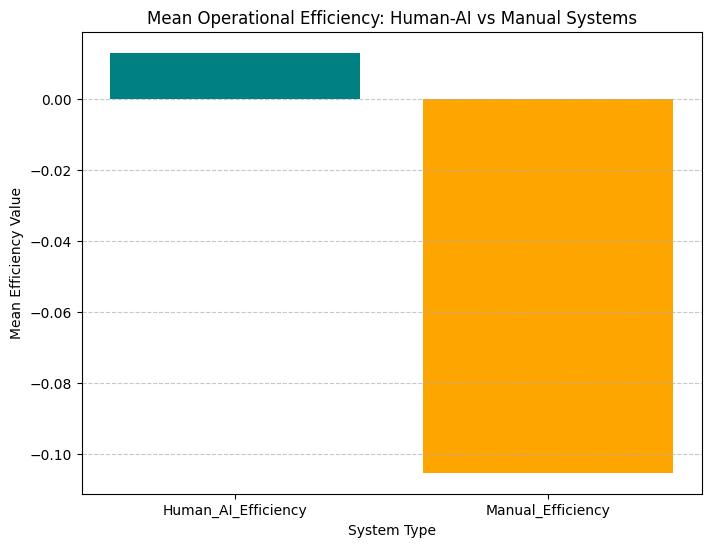

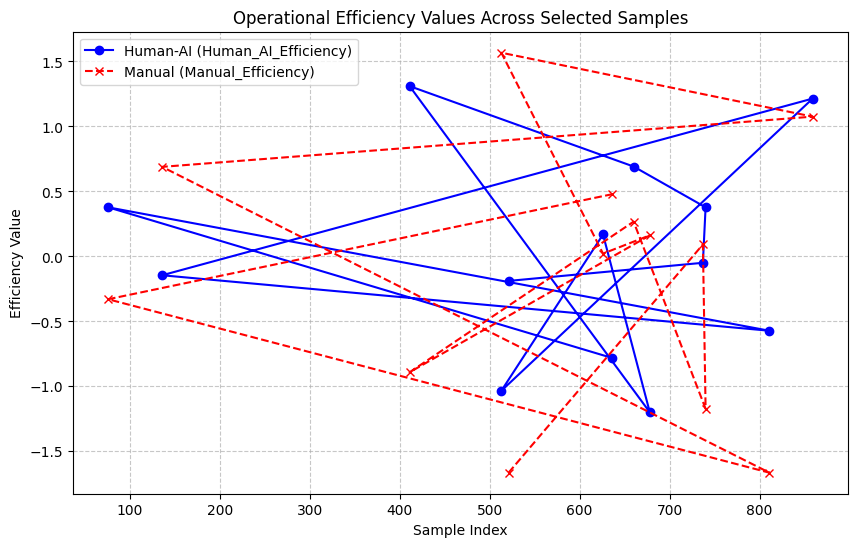

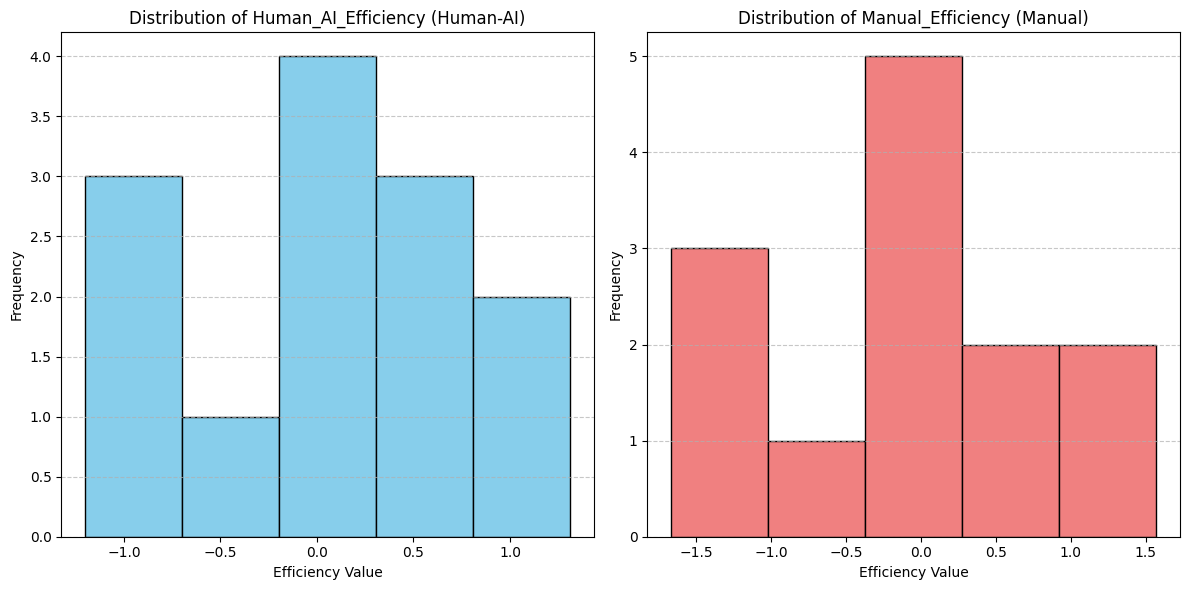

/tmp/ipykernel_1539/3954565246.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sampled_data[human_ai_col], sampled_data[manual_col]],


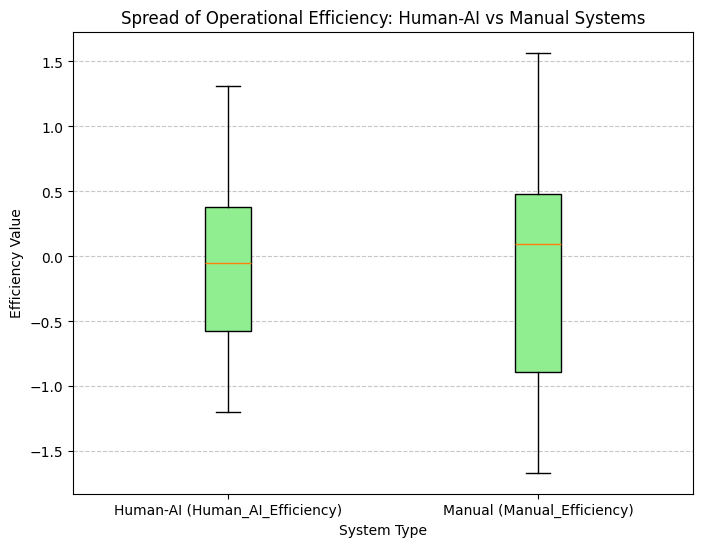

In [16]:
if 'human_ai_col' in locals() and 'manual_col' in locals() and human_ai_col and manual_col:
    # --- 6. Visualization (using matplotlib only) & 7. Graph Requirements ---

    # Bar chart comparing mean efficiency
    plt.figure(figsize=(8, 6))
    plt.bar([human_ai_col, manual_col], [mean_human_ai, mean_manual], color=['teal', 'orange'])
    plt.title('Mean Operational Efficiency: Human-AI vs Manual Systems')
    plt.xlabel('System Type')
    plt.ylabel('Mean Efficiency Value')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Line plot showing efficiency values across selected samples
    plt.figure(figsize=(10, 6))
    plt.plot(sampled_data.index, sampled_data[human_ai_col], marker='o', linestyle='-', color='blue', label=f'Human-AI ({human_ai_col})')
    plt.plot(sampled_data.index, sampled_data[manual_col], marker='x', linestyle='--', color='red', label=f'Manual ({manual_col})')
    plt.title('Operational Efficiency Values Across Selected Samples')
    plt.xlabel('Sample Index')
    plt.ylabel('Efficiency Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # Histograms for distribution of efficiencies
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    plt.hist(sampled_data[human_ai_col], bins=5, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {human_ai_col} (Human-AI)')
    plt.xlabel('Efficiency Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    plt.hist(sampled_data[manual_col], bins=5, color='lightcoral', edgecolor='black')
    plt.title(f'Distribution of {manual_col} (Manual)')
    plt.xlabel('Efficiency Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Boxplot comparing spread between both systems
    plt.figure(figsize=(8, 6))
    plt.boxplot([sampled_data[human_ai_col], sampled_data[manual_col]],
                labels=[f'Human-AI ({human_ai_col})', f'Manual ({manual_col})'],
                patch_artist=True, boxprops=dict(facecolor='lightgreen'))
    plt.title('Spread of Operational Efficiency: Human-AI vs Manual Systems')
    plt.xlabel('System Type')
    plt.ylabel('Efficiency Value')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Cannot generate visualizations as suitable numerical columns for efficiency analysis were not found.")
